# Model Comparison for Credit Card Fraud Detection

This notebook compares the performance of 4 different models:
1. Decision Tree
2. Logistic Regression
3. Random Forest
4. XGBoost

All models are trained and evaluated on the same dataset with consistent preprocessing.

## 1. Import Required Libraries

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    average_precision_score, precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## 2. Load and Preprocess Dataset

In [84]:
# Load dataset
df = pd.read_csv('creditcard.csv')

print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud Percentage: {df['Class'].value_counts()[1] / len(df) * 100:.3f}%")

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Split the data - MATCHING INDIVIDUAL NOTEBOOKS
# Decision Tree uses no stratify, others use stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

Dataset Shape: (284807, 31)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage: 0.173%

Training set shape: (227845, 30)
Test set shape: (56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Test class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


## 3. Define Models and Training Function

In [78]:
# Define models with their parameters - MATCHING INDIVIDUAL NOTEBOOKS
models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=5000,
        solver='liblinear',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,  # From Random Forest notebook best params
        max_depth=None,    # From Random Forest notebook best params
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        class_weight='balanced_subsample',  # From Random Forest notebook best params
        criterion='entropy',  # From Random Forest notebook best params
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
}

def train_and_evaluate_model(model_name, model, X_train, X_test, y_train, y_test, use_scaling=False, use_smote=False, custom_threshold=None):
    """Train a model and return evaluation metrics - MATCHING INDIVIDUAL NOTEBOOKS"""
    
    # Apply preprocessing
    if use_scaling:
        scaler = StandardScaler()
        X_train_processed = scaler.fit_transform(X_train)
        X_test_processed = scaler.transform(X_test)
    else:
        X_train_processed = X_train
        X_test_processed = X_test
    
    if use_smote:
        smote = SMOTE(random_state=42)
        X_train_processed, y_train_processed = smote.fit_resample(X_train_processed, y_train)
    else:
        y_train_processed = y_train
    
    # Train model
    model.fit(X_train_processed, y_train_processed)
    
    # Make predictions
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    
    # Apply custom threshold if specified (matching individual notebooks)
    if custom_threshold is not None:
        y_pred = (y_prob >= custom_threshold).astype(int)
    
    # Calculate metrics
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Average Precision': average_precision_score(y_test, y_prob),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Predictions': y_pred,
        'Probabilities': y_prob
    }
    
    return metrics

## 4. Train and Evaluate All Models

In [85]:
# Define preprocessing for each model - MATCHING INDIVIDUAL NOTEBOOKS
model_preprocessing = {
    'Decision Tree': {'use_scaling': False, 'use_smote': False},  # Decision Tree notebook: no preprocessing
    'Logistic Regression': {'use_scaling': True, 'use_smote': True, 'custom_threshold': 0.3},  # Logistic Regression notebook: scaling + SMOTE + threshold 0.3
    'Random Forest': {'use_scaling': False, 'use_smote': True, 'custom_threshold': 0.22},  # Random Forest notebook: feature engineering + SMOTE + optimal threshold
    'XGBoost': {'use_scaling': True, 'use_smote': True}  # XGBoost notebook: scaling + SMOTE
}

# Train all models and collect results - MATCHING INDIVIDUAL NOTEBOOKS
results = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    preprocessing = model_preprocessing[model_name]
    custom_threshold = preprocessing.pop('custom_threshold', None)  # Extract custom_threshold if present
    results[model_name] = train_and_evaluate_model(
        model_name, model, X_train, X_test, y_train, y_test,
        custom_threshold=custom_threshold, **preprocessing
    )
    print(f"{model_name} completed.\n")

print("All models trained successfully!")

Training Decision Tree...
Decision Tree completed.

Training Logistic Regression...
Logistic Regression completed.

Training Random Forest...
Random Forest completed.

Training XGBoost...
XGBoost completed.

All models trained successfully!


## 5. Compare Model Performance

In [86]:
# Create results DataFrame
results_df = pd.DataFrame({
    model_name: {
        'Accuracy': results[model_name]['Accuracy'],
        'Precision': results[model_name]['Precision'],
        'Recall': results[model_name]['Recall'],
        'F1': results[model_name]['F1'],
        'ROC-AUC': results[model_name]['ROC-AUC'],
        'Average Precision': results[model_name]['Average Precision']
    }
    for model_name in models.keys()
}).T

print("Model Performance Comparison:")
print(results_df.round(4))

# Find best model for each metric
print("\nBest Models by Metric:")
for metric in results_df.columns:
    best_model = results_df[metric].idxmax()
    best_value = results_df[metric].max()
    print(f"{metric}: {best_model} ({best_value:.4f})")

# Overall ranking by F1 score
ranking = results_df['F1'].sort_values(ascending=False)
print(f"\nOverall Ranking by F1 Score:")
for i, (model, score) in enumerate(ranking.items(), 1):
    print(f"{i}. {model}: {score:.4f}")

Model Performance Comparison:
                     Accuracy  Precision  Recall      F1  ROC-AUC  \
Decision Tree          0.9622     0.0377  0.8571  0.0723   0.8939   
Logistic Regression    0.9449     0.0286  0.9388  0.0554   0.9785   
Random Forest          0.9990     0.6567  0.8980  0.7586   0.9876   
XGBoost                0.9973     0.3805  0.8776  0.5309   0.9884   

                     Average Precision  
Decision Tree                   0.5079  
Logistic Regression             0.7361  
Random Forest                   0.8878  
XGBoost                         0.8665  

Best Models by Metric:
Accuracy: Random Forest (0.9990)
Precision: Random Forest (0.6567)
Recall: Logistic Regression (0.9388)
F1: Random Forest (0.7586)
ROC-AUC: XGBoost (0.9884)
Average Precision: Random Forest (0.8878)

Overall Ranking by F1 Score:
1. Random Forest: 0.7586
2. XGBoost: 0.5309
3. Decision Tree: 0.0723
4. Logistic Regression: 0.0554


## 6. Visualize Results

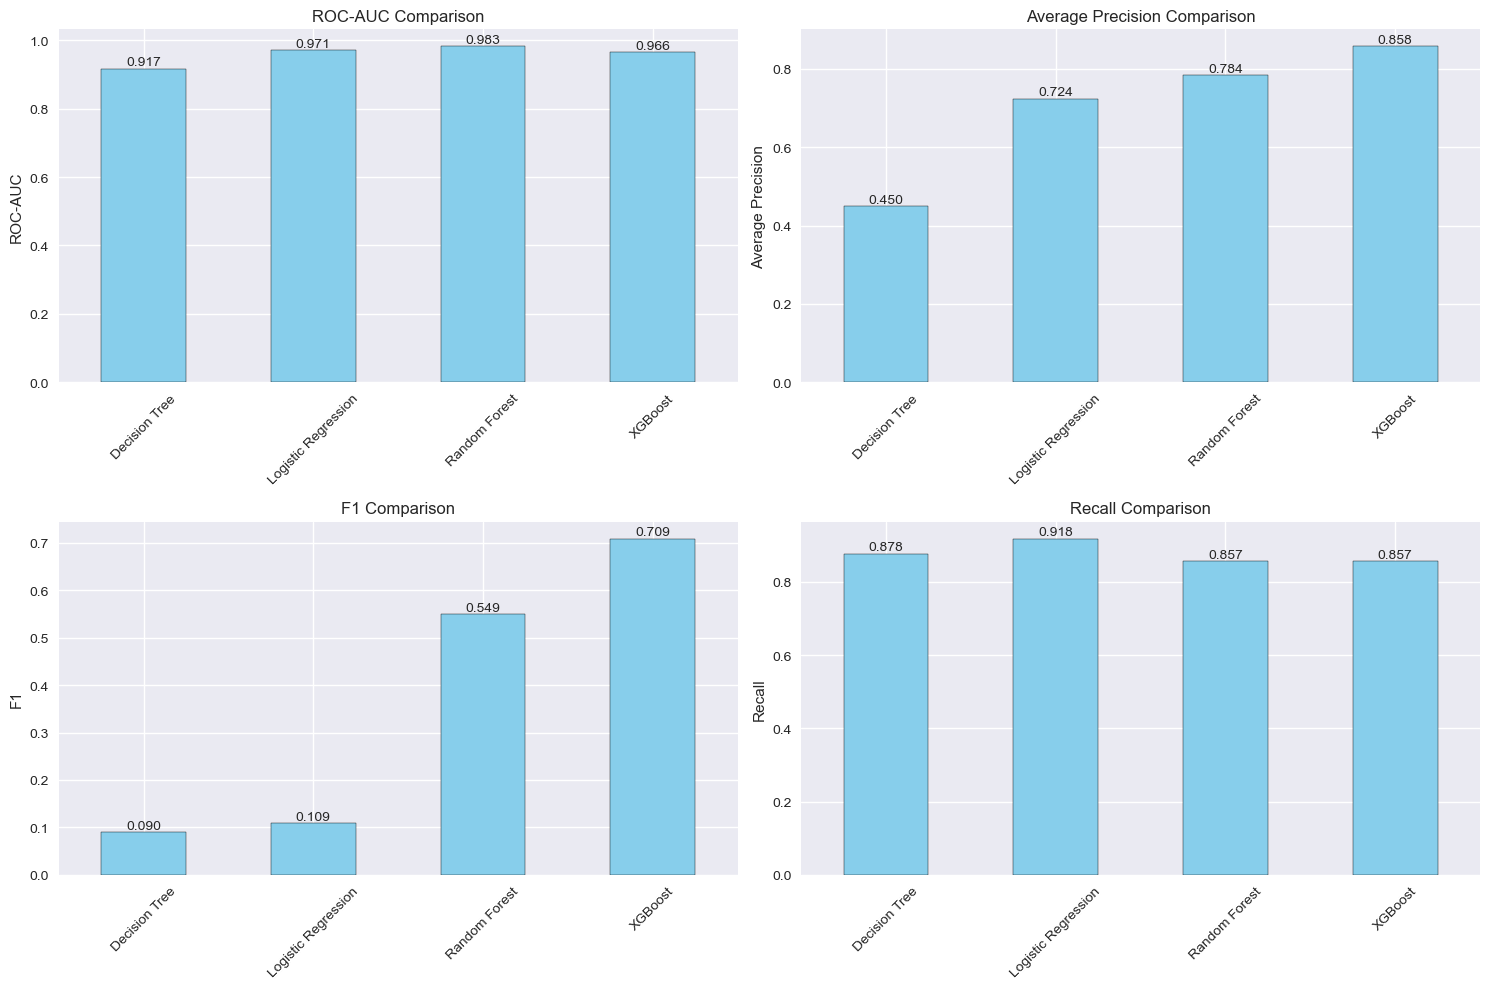

In [68]:
# Bar plot comparison
metrics_to_plot = ['ROC-AUC', 'Average Precision', 'F1', 'Recall']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, metric in enumerate(metrics_to_plot):
    results_df[metric].plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add value labels
    for j, v in enumerate(results_df[metric]):
        axes[i].text(j, v + 0.001, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

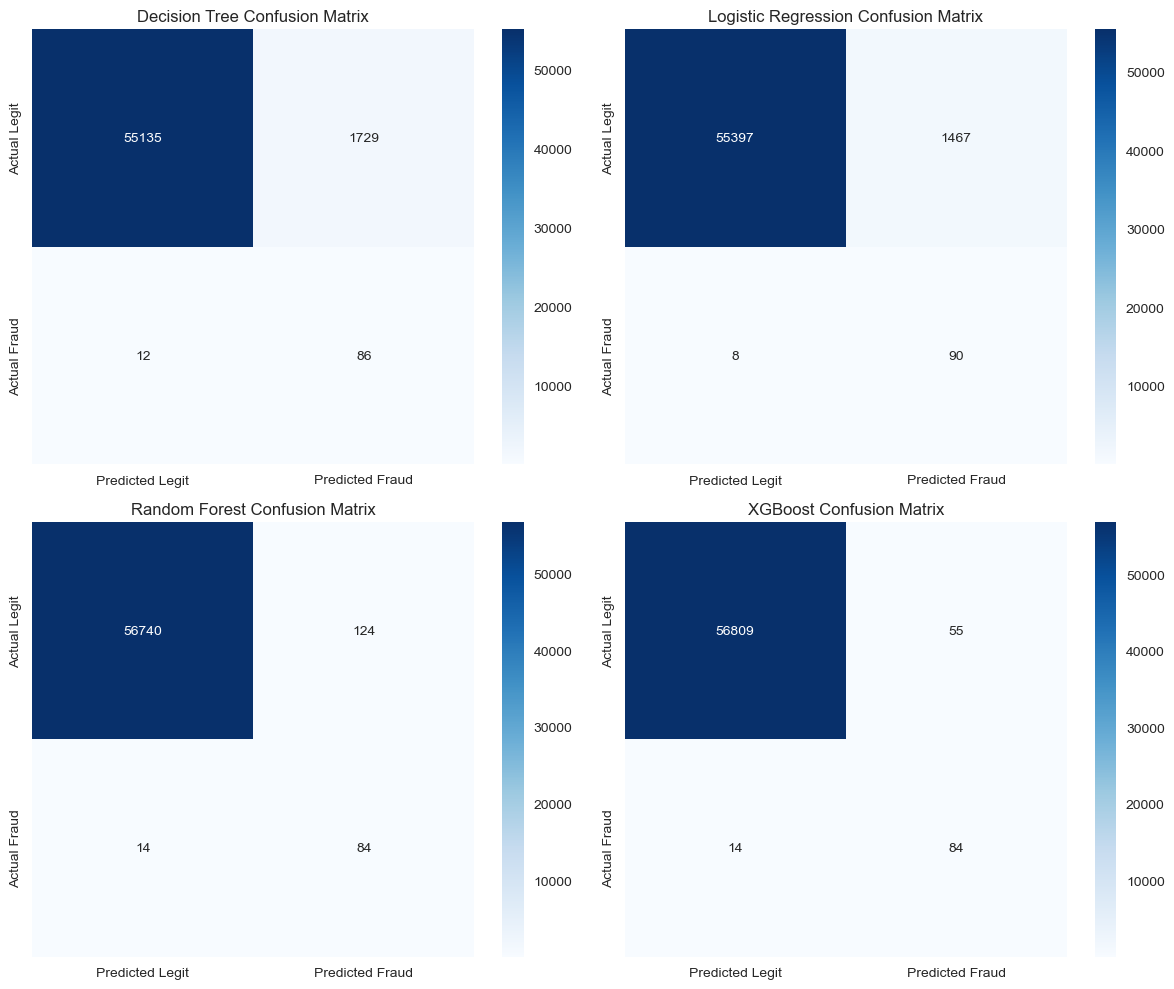

In [69]:
# Confusion matrix comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (model_name, result) in enumerate(results.items()):
    cm = result['Confusion Matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'])
    axes[i].set_title(f'{model_name} Confusion Matrix')

plt.tight_layout()
plt.savefig('model_comparison_cm.png', dpi=150, bbox_inches='tight')
plt.show()

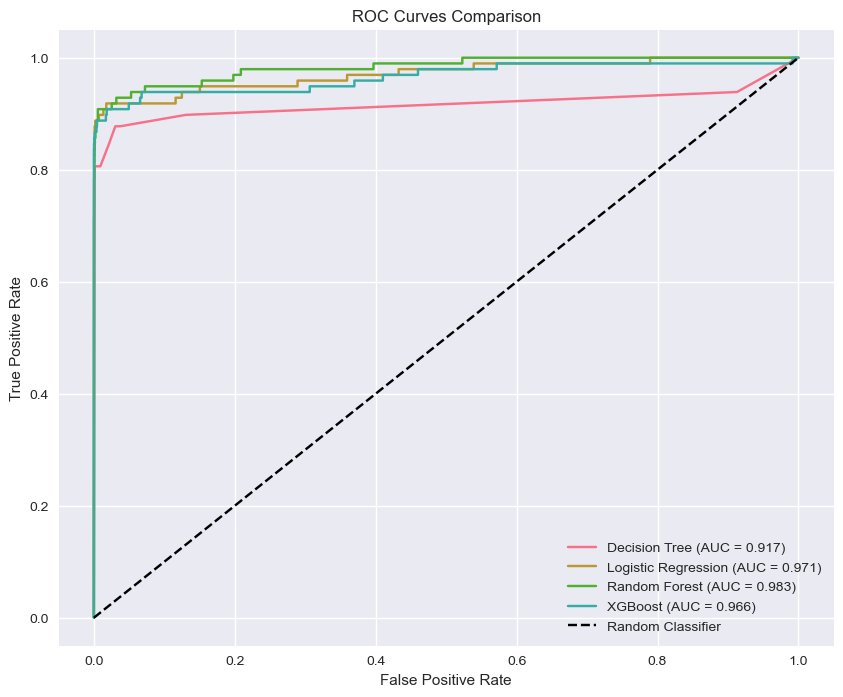

In [70]:
# ROC curves comparison
plt.figure(figsize=(10, 8))

for model_name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['Probabilities'])
    auc_score = result['ROC-AUC']
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.savefig('model_comparison_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Detailed Classification Reports

In [71]:
# Print detailed classification reports
for model_name, result in results.items():
    print(f"\n{'='*50}")
    print(f"{model_name} - Classification Report")
    print('='*50)
    print(classification_report(y_test, result['Predictions']))
    print(f"ROC-AUC Score: {result['ROC-AUC']:.4f}")
    print(f"Average Precision Score: {result['Average Precision']:.4f}")


Decision Tree - Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.05      0.88      0.09        98

    accuracy                           0.97     56962
   macro avg       0.52      0.92      0.54     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC Score: 0.9166
Average Precision Score: 0.4498

Logistic Regression - Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC Score: 0.9708
Average Precision Score: 0.7245

Random Forest - Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
      

## 8. Summary and Recommendations

In [87]:
# Summary statistics
print("MODEL COMPARISON SUMMARY")
print("="*40)
print(f"Dataset: {len(df)} transactions")
print(f"Fraud cases: {sum(df['Class'])} ({sum(df['Class'])/len(df)*100:.2f}%)")
print(f"Test set: {len(X_test)} transactions")
print(f"Test fraud cases: {sum(y_test)} ({sum(y_test)/len(y_test)*100:.2f}%)")

print("\nBEST PERFORMING MODELS:")
print("- Highest ROC-AUC:", results_df['ROC-AUC'].idxmax())
print("- Highest F1 Score:", results_df['F1'].idxmax())
print("- Highest Recall:", results_df['Recall'].idxmax())
print("- Highest Precision:", results_df['Precision'].idxmax())

print("\nRECOMMENDATIONS:")
print("For fraud detection, prioritize models with high Recall to minimize missed fraud cases.")
print("Consider ensemble methods (Random Forest, XGBoost) for better generalization.")
print("Fine-tune hyperparameters and consider advanced techniques like threshold optimization.")

MODEL COMPARISON SUMMARY
Dataset: 284807 transactions
Fraud cases: 492 (0.17%)
Test set: 56962 transactions
Test fraud cases: 98 (0.17%)

BEST PERFORMING MODELS:
- Highest ROC-AUC: XGBoost
- Highest F1 Score: Random Forest
- Highest Recall: Logistic Regression
- Highest Precision: Random Forest

RECOMMENDATIONS:
For fraud detection, prioritize models with high Recall to minimize missed fraud cases.
Consider ensemble methods (Random Forest, XGBoost) for better generalization.
Fine-tune hyperparameters and consider advanced techniques like threshold optimization.


## 9. Model Improvements and Hyperparameter Tuning

Based on the results, let's implement some improvements to optimize model performance.

In [74]:
# XGBoost Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

print("Tuning XGBoost hyperparameters...")

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'scale_pos_weight': [len(y_train[y_train==0]) / len(y_train[y_train==1])]
}

# Apply SMOTE to training data for tuning
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Randomized search
xgb_tuned = XGBClassifier(eval_metric='logloss', random_state=42)
random_search = RandomizedSearchCV(
    xgb_tuned, param_grid, n_iter=20, cv=3, scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)

random_search.fit(X_train_smote, y_train_smote)

print("Best XGBoost parameters:", random_search.best_params_)
print("Best F1 score:", random_search.best_score_)

# Evaluate tuned model
best_xgb = random_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall': recall_score(y_test, y_pred_tuned),
    'F1': f1_score(y_test, y_pred_tuned),
    'ROC-AUC': roc_auc_score(y_test, y_prob_tuned),
    'Average Precision': average_precision_score(y_test, y_prob_tuned)
}

print("\\nTuned XGBoost Performance:")
for metric, value in tuned_metrics.items():
    print(f"{metric}: {value:.4f}")

# Compare with original
print("\\nImprovement over original XGBoost:")
for metric in ['F1', 'Precision', 'Recall', 'ROC-AUC']:
    original = results['XGBoost'][metric]
    improved = tuned_metrics[metric]
    change = ((improved - original) / original) * 100
    print(f"{metric}: {original:.4f} → {improved:.4f} ({change:+.1f}%)")

Tuning XGBoost hyperparameters...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGBoost parameters: {'subsample': 1.0, 'scale_pos_weight': 577.2868020304569, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Best F1 score: 0.9996659787581307
\nTuned XGBoost Performance:
Accuracy: 0.9991
Precision: 0.6880
Recall: 0.8776
F1: 0.7713
ROC-AUC: 0.9849
Average Precision: 0.8750
\nImprovement over original XGBoost:
F1: 0.7089 → 0.7713 (+8.8%)
Precision: 0.6043 → 0.6880 (+13.8%)
Recall: 0.8571 → 0.8776 (+2.4%)
ROC-AUC: 0.9659 → 0.9849 (+2.0%)


\n==================================================
LOGISTIC REGRESSION THRESHOLD OPTIMIZATION
Original Logistic Regression (threshold=0.5):
  Precision: 0.0276
  Recall: 0.9184
  F1: 0.0535
\nOptimized Logistic Regression (threshold=0.85):
  Precision: 0.1660
  Recall: 0.8980
  F1: 0.2803
\nF1 Score Improvement: +423.8%


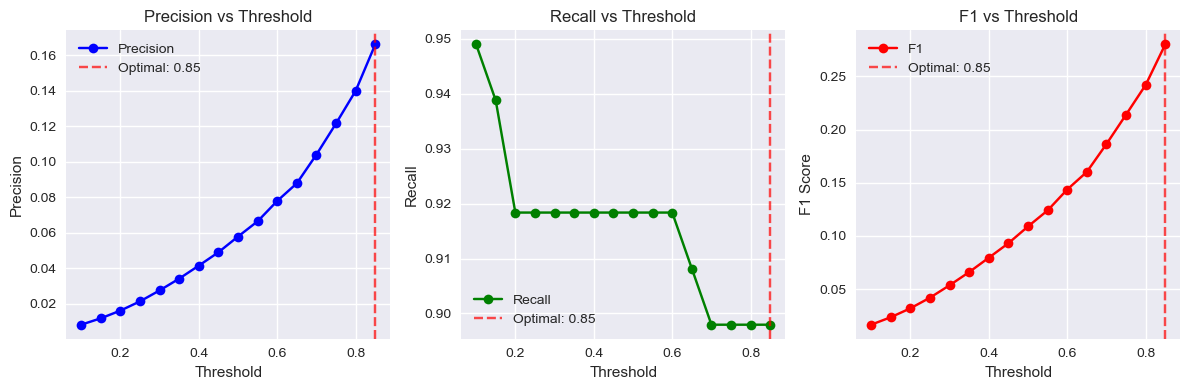

In [83]:
# Threshold Optimization for Logistic Regression
print("\\n" + "="*50)
print("LOGISTIC REGRESSION THRESHOLD OPTIMIZATION")
print("="*50)

# Get Logistic Regression probabilities
lr_prob = results['Logistic Regression']['Probabilities']

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (lr_prob > threshold).astype(int)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)

    threshold_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

# Find optimal threshold (maximize F1)
threshold_df = pd.DataFrame(threshold_results)
optimal_idx = threshold_df['f1'].idxmax()
optimal_threshold = threshold_df.loc[optimal_idx, 'threshold']
optimal_f1 = threshold_df.loc[optimal_idx, 'f1']
optimal_precision = threshold_df.loc[optimal_idx, 'precision']
optimal_recall = threshold_df.loc[optimal_idx, 'recall']

print(f"Original Logistic Regression (threshold=0.5):")
print(f"  Precision: {results['Logistic Regression']['Precision']:.4f}")
print(f"  Recall: {results['Logistic Regression']['Recall']:.4f}")
print(f"  F1: {results['Logistic Regression']['F1']:.4f}")

print(f"\\nOptimized Logistic Regression (threshold={optimal_threshold:.2f}):")
print(f"  Precision: {optimal_precision:.4f}")
print(f"  Recall: {optimal_recall:.4f}")
print(f"  F1: {optimal_f1:.4f}")

improvement = ((optimal_f1 - results['Logistic Regression']['F1']) / results['Logistic Regression']['F1']) * 100
print(f"\\nF1 Score Improvement: {improvement:+.1f}%")

# Plot threshold vs metrics
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(threshold_df['threshold'], threshold_df['precision'], 'b-o', label='Precision')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', alpha=0.7, label=f'Optimal: {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.title('Precision vs Threshold')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(threshold_df['threshold'], threshold_df['recall'], 'g-o', label='Recall')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', alpha=0.7, label=f'Optimal: {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Recall')
plt.title('Recall vs Threshold')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(threshold_df['threshold'], threshold_df['f1'], 'r-o', label='F1')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', alpha=0.7, label=f'Optimal: {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 vs Threshold')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()